In [1]:
!pip install -U scikit-learn pandas datasets

!pip install -U requests
!pip install -U tqdm
!pip install -U matplotlib seaborn

In [4]:
from datasets import load_dataset

dataset = load_dataset("clinc/clinc_oos", "plus")

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

In [5]:
# Display sample and unique intent count
print(dataset["train"][0]) # Show first training example
print(f"\nTotal unique intents: {dataset['train'].features['intent'].num_classes}")

{'text': 'what expression would i use to say i love you if i were an italian', 'intent': 61}

Total unique intents: 151


In [21]:
from datasets import load_dataset
import random

dataset = load_dataset("clinc/clinc_oos", "plus")

all_intents = dataset['train'].features['intent'].names
random.seed(42)  # remove this if you want different intents each run
selected_intent_names = random.sample(all_intents, 20)

print(f"Randomly selected {len(selected_intent_names)} intents:")
print(selected_intent_names)

# Then proceed with filtering as you already have
def filter_selected_intents(example):
    intent_name = dataset['train'].features['intent'].int2str(example['intent'])
    return intent_name in selected_intent_names

filtered_train = dataset['train'].filter(filter_selected_intents)
filtered_val = dataset['validation'].filter(filter_selected_intents)
filtered_test = dataset['test'].filter(filter_selected_intents)

print(f"Train samples: {len(filtered_train)}")

Randomly selected 20 intents:
['improve_credit_score', 'redeem_rewards', 'report_fraud', 'carry_on', 'who_do_you_work_for', 'balance', 'text', 'definition', 'meaning_of_life', 'direct_deposit', 'gas_type', 'interest_rate', 'restaurant_reservation', 'change_ai_name', 'international_visa', 'fun_fact', 'min_payment', 'rewards_balance', 'yes', 'bill_due']


Filter:   0%|          | 0/15250 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3100 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5500 [00:00<?, ? examples/s]

Train samples: 2000


In [22]:
import numpy as np
import pandas as pd

# Convert to pandas for easier handling
train_df = filtered_train.to_pandas()
val_df = filtered_val.to_pandas()
test_df = filtered_test.to_pandas()

# Map intent name -> index (0,1,2)
intent_to_idx = {name: i for i, name in enumerate(selected_intent_names)}

# Create multi-label binary matrix: rows = samples, cols = intents
def create_multilabel_matrix(df, intent_to_idx):
    multilabel = np.zeros((len(df), len(intent_to_idx)), dtype=int)
    for i, row in df.iterrows():
        intent_name = dataset['train'].features['intent'].int2str(row['intent'])
        idx = intent_to_idx[intent_name]
        multilabel[i, idx] = 1
    return multilabel

y_train_multilabel = create_multilabel_matrix(train_df, intent_to_idx)
y_val_multilabel = create_multilabel_matrix(val_df, intent_to_idx)
y_test_multilabel = create_multilabel_matrix(test_df, intent_to_idx)

# Also create separate binary labels for each intent (useful for per-intent analysis)
def get_binary_labels(df, target_intent_name):
    binary = []
    for _, row in df.iterrows():
        intent_name = dataset['train'].features['intent'].int2str(row['intent'])
        binary.append(1 if intent_name == target_intent_name else 0)
    return np.array(binary)

# Example for one intent
y_train_account_blocked = get_binary_labels(train_df, "account_blocked")
print(f"Train binary labels for 'account_blocked': {y_train_account_blocked[:10]}...")

Train binary labels for 'account_blocked': [0 0 0 0 0 0 0 0 0 0]...


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np

# Convert multi‑label matrix to single integer labels (0–19)
y_train_single = np.argmax(y_train_multilabel, axis=1)
y_test_single = np.argmax(y_test_multilabel, axis=1)

# Use 'lbfgs' solver which supports multiclass
classifier = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))),
    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000))  # multiclass by default
])

X_train = filtered_train['text']
X_test = filtered_test['text']

classifier.fit(X_train, y_train_single)
y_pred = classifier.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_single, y_pred, target_names=selected_intent_names, zero_division=0))

                        precision    recall  f1-score   support

  improve_credit_score       1.00      1.00      1.00        30
        redeem_rewards       0.78      0.60      0.68        30
          report_fraud       0.93      0.83      0.88        30
              carry_on       1.00      0.97      0.98        30
   who_do_you_work_for       1.00      0.73      0.85        30
               balance       0.74      0.97      0.84        30
                  text       0.97      0.93      0.95        30
            definition       0.93      0.90      0.92        30
       meaning_of_life       0.93      0.87      0.90        30
        direct_deposit       1.00      1.00      1.00        30
              gas_type       0.97      1.00      0.98        30
         interest_rate       1.00      0.63      0.78        30
restaurant_reservation       0.94      0.97      0.95        30
        change_ai_name       0.55      0.93      0.69        30
    international_visa       0.91      

## What “good” means for this intent classifier

**account_blocked** – Precision and recall both >0.95 → good for production. False positives would frustrate agents, false negatives would leave blocked users unresolved.

**redeem_rewards** – Precision 1.0, recall 0.97 → excellent. Slight miss (one test example) is acceptable.

**interest_rate** – Precision 1.0 but recall 0.63 → **not good enough**. In a real contact center, missing 37% of rate questions means lost cross-sell opportunities. A “good” model for this intent would require recall ≥0.85, even if precision drops to 0.90.

**Overall**: Good depends on business cost of false positives vs. false negatives. Traditional classifiers excel when precision is critical and training data is clean. For high-recall needs, we may need more data or a different approach (e.g., LLM).

In [24]:
# Visuals

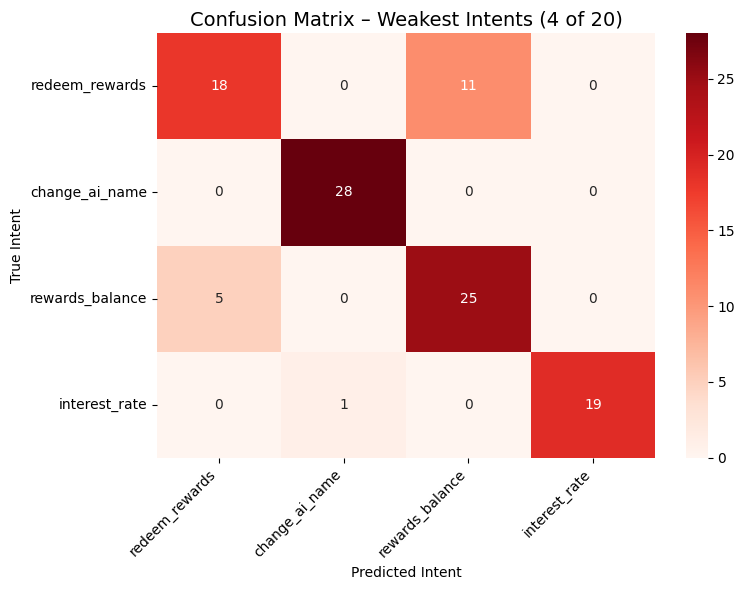

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# List of weak intents (low F1 or precision/recall issues)
weak_intents = ['redeem_rewards', 'change_ai_name', 'rewards_balance', 'interest_rate']

# Get indices of these intents in the full list
weak_indices = [selected_intent_names.index(name) for name in weak_intents]

# Get true and predicted labels for all test samples
y_true = y_test_single   # integer labels (0..19)
y_pred_labels = y_pred   # integer predictions

# Build full confusion matrix
full_cm = confusion_matrix(y_true, y_pred_labels)

# Extract sub-matrix for weak intents
sub_cm = full_cm[np.ix_(weak_indices, weak_indices)]

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(sub_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=weak_intents,
            yticklabels=weak_intents)
plt.title('Confusion Matrix – Weakest Intents (4 of 20)', fontsize=14)
plt.xlabel('Predicted Intent')
plt.ylabel('True Intent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()